<a href="https://colab.research.google.com/github/akashgardas/freight-rail-delay-prediction/blob/model-building/notebooks/model_building/KNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Build K-Nearest Neighbors Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
path = '/content/drive/MyDrive/CVR College/Mini Project/data/Finalized data/preprocessed_data.csv'

## Load

In [3]:
df = pd.read_csv(path)
df.head()

,arrival_delay_time,teu_count,train_length,total_distance_trip,departure_delay_time,weight_per_length,weight_per_wagon
0,0,0.0,420.0,364,0,990.0,18900.0
1,0,0.0,420.0,364,0,990.0,18900.0
2,0,0.0,420.0,364,0,990.0,18900.0
3,0,0.0,420.0,364,0,990.0,18900.0
4,0,0.0,420.0,364,0,990.0,18900.0


In [4]:
df.columns

Index(['arrival_delay_time', 'teu_count', 'train_length',
       'total_distance_trip', 'departure_delay_time', 'weight_per_length',
       'weight_per_wagon'],
      dtype='object')

## Feature separation

In [5]:
X = df.drop('arrival_delay_time', axis=1)
y = df['arrival_delay_time']

## Train Test split

In [6]:
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Standardization

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Hyperparameter Tuning

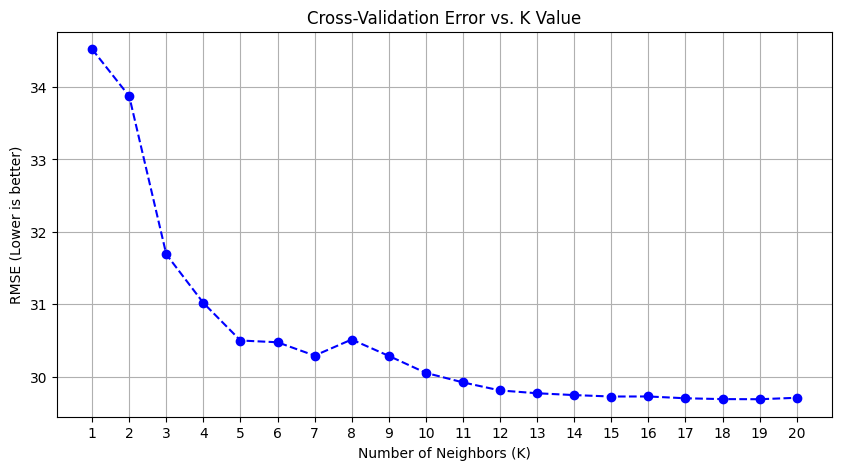

The optimal number of neighbors (K) is: 19


In [8]:
# Test K values from 1 to 20 to find the best performing model
k_values = range(1, 21)
cv_rmse_scores = []

for k in k_values:
    knn_cv = KNeighborsRegressor(n_neighbors=k, weights='distance')
    # Use 5-fold cross-validation
    scores = cross_val_score(knn_cv, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_rmse_scores.append(np.mean(np.sqrt(-scores)))

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_rmse_scores, marker='o', linestyle='--', color='b')
plt.title('Cross-Validation Error vs. K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('RMSE (Lower is better)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

best_k = k_values[np.argmin(cv_rmse_scores)]
print(f"The optimal number of neighbors (K) is: {best_k}")

## Build Model

In [9]:
knn = KNeighborsRegressor(n_neighbors=13, weights='distance')

# Train the model
knn.fit(X_train_scaled, y_train)

KNeighborsRegressor(n_neighbors=13, weights='distance')

## Evaluate Model

In [10]:
# Predict delay times on the unseen test set
y_pred = knn.predict(X_test_scaled)

# Calculate error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE):      {mae:.2f}")
print(f"R-squared Score (R2):           {r2:.4f}")

--- Model Evaluation ---
Root Mean Squared Error (RMSE): 30.23
Mean Absolute Error (MAE):      16.18
R-squared Score (R2):           0.1612


## Export Model

In [11]:
# Export model
import joblib

# Export the model to a file
joblib.dump(knn, 'knn_regressor.joblib')

# Export the fitted scaler
joblib.dump(scaler, 'knn_scaler.joblib')

# --- To load it back later ---
# loaded_model = joblib.load('my_model.joblib')

['knn_scaler.joblib']